Butterfly spreads are options strategies that involve using four options contracts with three different strike prices. Butterfly spreads offer limited risk but also have capped profit potential.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [2]:
S = np.linspace(50, 150, 500)

In [3]:
# Black-Scholes pricing formulas
def bs_call_price(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def bs_put_price(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

In [4]:
r = 0.01          # Risk-free rate
sigma = 0.25      # Volatility
T = 30 / 365      # Time to expiration in years

---
## STRATEGIES TO PROFIT FROM LOW-VOLATILITY ENVIRONMENTS
---

**Long-call butterfly spread**: 1 Long ITM call + 2 Short ATM calls + 1 Long OTM call

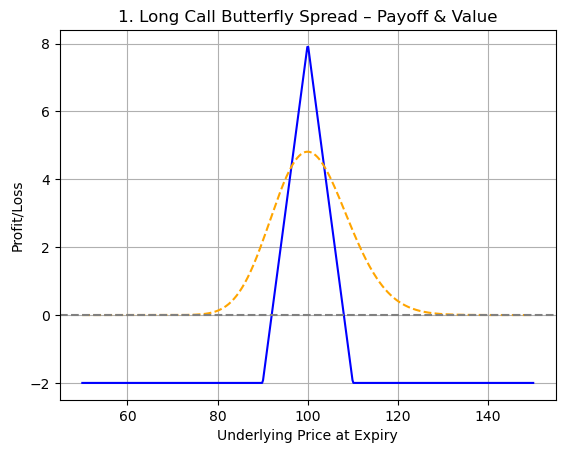

In [5]:
def long_call_butterfly_payoff(K1, K2, K3, P1, P2, P3, S):
    return np.maximum(S - K1, 0) - P1 - 2 * (np.maximum(S - K2, 0) - P2) + np.maximum(S - K3, 0) - P3

def long_call_butterfly_value(K1, K2, K3, S, T, r, sigma):
    return bs_call_price(S, K1, T, r, sigma) - 2 * bs_call_price(S, K2, T, r, sigma) + bs_call_price(S, K3, T, r, sigma)

payoff = long_call_butterfly_payoff(90, 100, 110, 12, 7, 4, S)
value = long_call_butterfly_value(90, 100, 110, S, T, r, sigma)

plt.plot(S, payoff, label='Payoff at Expiry', color='blue')
plt.plot(S, value, label=f'Value ({int(T*365)} days to expiry', linestyle='--', color='orange')
plt.axhline(0, color='gray', linestyle='--')
plt.title("1. Long Call Butterfly Spread – Payoff & Value")
plt.xlabel("Underlying Price at Expiry")
plt.ylabel("Profit/Loss")
plt.grid(True)
plt.show()

S ≤ K1: All options expire worthless → Max loss = Net Premium Paid

K1 < S < K2: ITM call gains and short calls are worthless

S = K2:	Max profit (long call gains, shorts are ATM, OTM not triggered)

K2 < S < K3: Short calls go deeper ITM thus offsetting gains

S ≥ K3:	All calls are ITM so gains/losses cancel out → Max loss = Net Premium Paid

**Long-put butterfly spread**: 1 Long ITM put + 2 Short ATM put + 1 Long OTM put

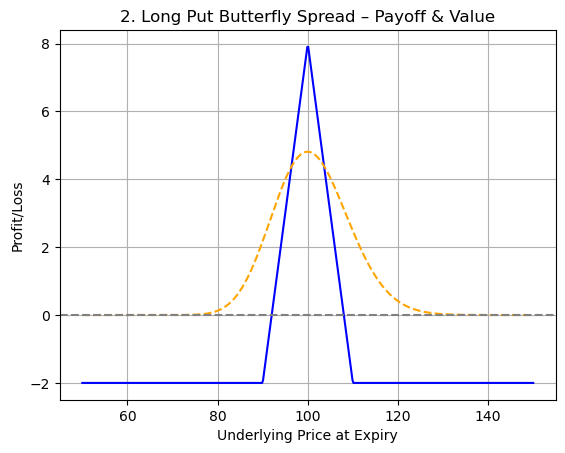

In [6]:
def long_put_butterfly_payoff(K1, K2, K3, P1, P2, P3, S):
    return np.maximum(K1 - S, 0) - P1 - 2 * (np.maximum(K2 - S, 0) - P2) + np.maximum(K3 - S, 0) - P3

def long_put_butterfly_value(K1, K2, K3, S, T, r, sigma):
    return bs_put_price(S, K1, T, r, sigma) - 2 * bs_put_price(S, K2, T, r, sigma) + bs_put_price(S, K3, T, r, sigma)

payoff = long_put_butterfly_payoff(110, 100, 90, 12, 7, 4, S)
value = long_put_butterfly_value(110, 100, 90, S, T, r, sigma)

plt.plot(S, payoff, label='Payoff at Expiry', color='blue')
plt.plot(S, value, label=f'Value ({int(T*365)} days to expiry', linestyle='--', color='orange')
plt.axhline(0, color='gray', linestyle='--')
plt.title("2. Long Put Butterfly Spread – Payoff & Value")
plt.xlabel("Underlying Price at Expiry")
plt.ylabel("Profit/Loss")
plt.grid(True)
plt.show()

S ≥ K1:	All puts worthless → Max Loss = Net Premium Paid

K1 > S > K2: ITM put gains, other puts are worthless

S = K2:	Max profit (long put gains, shorts ATM, OTM inactive)

K2 > S > K3: Short puts cost more than long gains

S ≤ K3:	All puts ITM so losses/gains cancel out → Max Loss = Net Premium Paid

**Iron butterfly spread**: 1 Short ATM call + 1 Short ATM put + 1 Long OTM call + 1 Long OTM put

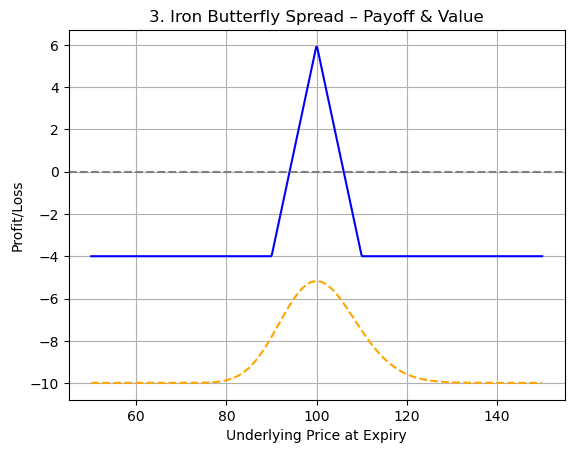

In [7]:
def iron_butterfly_payoff(K_put_low, K_mid, K_call_high, P_put_low, P_put_mid, P_call_mid, P_call_high, S):
    return -(np.maximum(K_mid - S, 0) - P_put_mid) + (np.maximum(K_put_low - S, 0) - P_put_low) - (np.maximum(S - K_mid, 0) - P_call_mid) + (np.maximum(S - K_call_high, 0) - P_call_high)

def iron_butterfly_value(K_put_low, K_mid, K_call_high, S, T, r, sigma):
    return -bs_put_price(S, K_mid, T, r, sigma) + bs_put_price(S, K_put_low, T, r, sigma) - bs_call_price(S, K_mid, T, r, sigma) + bs_call_price(S, K_call_high, T, r, sigma)

payoff = iron_butterfly_payoff(90, 100, 110, 4, 7, 7, 4, S)
value = iron_butterfly_value(90, 100, 110, S, T, r, sigma)

plt.plot(S, payoff, label='Payoff at Expiry', color='blue')
plt.plot(S, value, label=f'Value ({int(T*365)} days to expiry', linestyle='--', color='orange')
plt.axhline(0, color='gray', linestyle='--')
plt.title("3. Iron Butterfly Spread – Payoff & Value")
plt.xlabel("Underlying Price at Expiry")
plt.ylabel("Profit/Loss")
plt.grid(True)
plt.show()


S = K2:	All options expire worthless → Max profit = Net Premium Received

K1 < S < K2:	Short put is ITM and long put is OTM, leading to partial loss offset by the net premium received

K2 < S < K3:	Short call is ITM and long call is OTM, leading to partial loss offset by the net premium received

S ≤ K1:	Both puts ITM → Max loss = Spread Width − Net Premium Received

S ≥ K3:	Both calls ITM → Max loss = Spread Width − Net Premium Received

---
## STRATEGIES TO PROFIT FROM HIGH-VOLATILITY ENVIRONMENTS
---

**Short-call butterfly spread**: 1 Short ITM call + 2 Long ATM calls + 1 Short OTM call

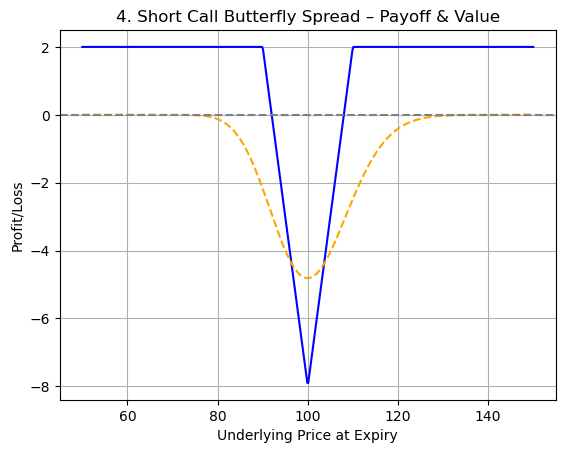

In [8]:
def short_call_butterfly_payoff(K1, K2, K3, P1, P2, P3, S):
    return -(np.maximum(S - K1, 0) - P1) + 2 * (np.maximum(S - K2, 0) - P2) - (np.maximum(S - K3, 0) - P3)

def short_call_butterfly_value(K1, K2, K3, S, T, r, sigma):
    return -bs_call_price(S, K1, T, r, sigma) + 2 * bs_call_price(S, K2, T, r, sigma) - bs_call_price(S, K3, T, r, sigma)

payoff = short_call_butterfly_payoff(90, 100, 110, 12, 7, 4, S)
value = short_call_butterfly_value(90, 100, 110, S, T, r, sigma)

plt.plot(S, payoff, label='Payoff at Expiry', color='blue')
plt.plot(S, value, label=f'Value ({int(T*365)} days to expiry', linestyle='--', color='orange')
plt.axhline(0, color='gray', linestyle='--')
plt.title("4. Short Call Butterfly Spread – Payoff & Value")
plt.xlabel("Underlying Price at Expiry")
plt.ylabel("Profit/Loss")
plt.grid(True)
plt.show()

S = K2:	Both long calls are ATM → Max loss

K1 < S < K2: Long calls are ITM and short calls are not yet problematic

K2 < S < K3: Short calls go deeper ITM, long calls partially offset the loss

S ≤ K1 or S ≥ K3: All options expire worthless or offset each other → Max profit = Net Premium Received

**Short-put butterfly spread**: 1 Short ITM put + 2 Long ATM put + 1 Short OTM put

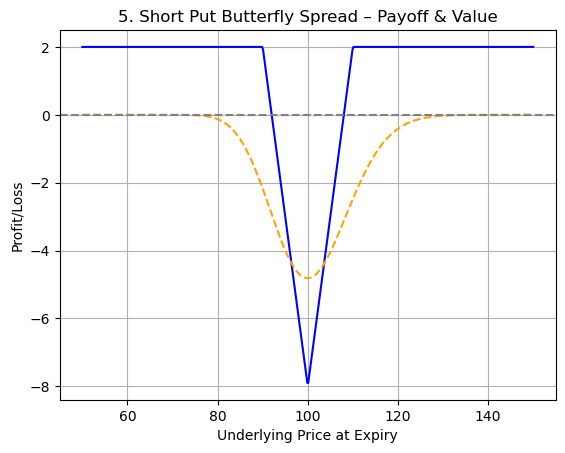

In [9]:
def short_put_butterfly_payoff(K1, K2, K3, P1, P2, P3, S):
    return -(np.maximum(K1 - S, 0) - P1) + 2 * (np.maximum(K2 - S, 0) - P2) - (np.maximum(K3 - S, 0) - P3)

def short_put_butterfly_value(K1, K2, K3, S, T, r, sigma):
    return -bs_put_price(S, K1, T, r, sigma) + 2 * bs_put_price(S, K2, T, r, sigma) - bs_put_price(S, K3, T, r, sigma)
    
payoff = short_put_butterfly_payoff(110, 100, 90, 12, 7, 4, S)
value = short_put_butterfly_value(110, 100, 90, S, T, r, sigma)

plt.plot(S, payoff, label='Payoff at Expiry', color='blue')
plt.plot(S, value, label=f'Value ({int(T*365)} days to expiry', linestyle='--', color='orange')
plt.axhline(0, color='gray', linestyle='--')
plt.title("5. Short Put Butterfly Spread – Payoff & Value")
plt.xlabel("Underlying Price at Expiry")
plt.ylabel("Profit/Loss")
plt.grid(True)
plt.show()

S = K2:	Both long puts are ATM → Max loss

K3 < S < K2: Long puts are ITM, but short puts cost more

K2 < S < K1: Short puts go deeper ITM, long puts partially offset the loss

S ≤ K3 or S ≥ K1: All options expire worthless or gains/losses cancel out → Max profit = Net Premium Received

**Reverse iron butterfly spread**: 1 Long ATM call + 1 Long ATM put + 1 Short OTM call + 1 Short OTM put

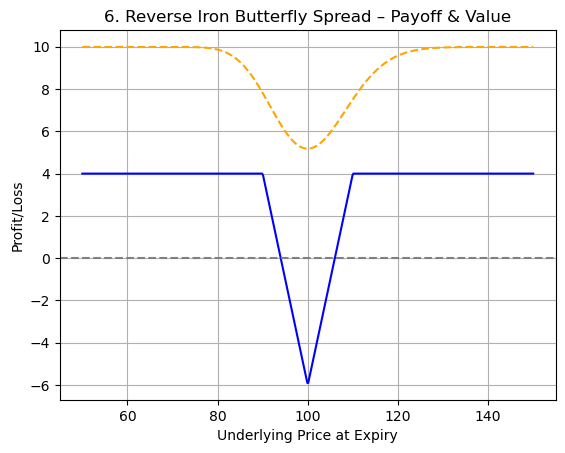

In [10]:
def reverse_iron_butterfly_payoff(K_put_low, K_mid, K_call_high, P_put_low, P_put_mid, P_call_mid, P_call_high, S):
    return (np.maximum(K_mid - S, 0) - P_put_mid) - (np.maximum(K_put_low - S, 0) - P_put_low) + (np.maximum(S - K_mid, 0) - P_call_mid) - (np.maximum(S - K_call_high, 0) - P_call_high)

def reverse_iron_butterfly_value(K_put_low, K_mid, K_call_high, S, T, r, sigma):
    return bs_put_price(S, K_mid, T, r, sigma) - bs_put_price(S, K_put_low, T, r, sigma) + bs_call_price(S, K_mid, T, r, sigma) - bs_call_price(S, K_call_high, T, r, sigma)

payoff = reverse_iron_butterfly_payoff(90, 100, 110, 4, 7, 7, 4, S)
value = reverse_iron_butterfly_value(90, 100, 110, S, T, r, sigma)

plt.plot(S, payoff, label='Payoff at Expiry', color='blue')
plt.plot(S, value, label=f'Value ({int(T*365)} days to expiry', linestyle='--', color='orange')
plt.axhline(0, color='gray', linestyle='--')
plt.title("6. Reverse Iron Butterfly Spread – Payoff & Value")
plt.xlabel("Underlying Price at Expiry")
plt.ylabel("Profit/Loss")
plt.grid(True)
plt.show()


S = K2: All options expire worthless → Max loss = Net Premium Paid

K1 < S < K2: Long put becomes ITM, short put is not triggered

K2 < S < K3: Long call becomes ITM, short call is not triggered

S ≤ K1:	Long put deeply ITM, short put caps loss → Max profit = Spread − Net Premium Paid

S ≥ K3:	Long call deeply ITM, short call caps loss → Max profit = Spread − Net Premium Paid